In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sympy import symbols, diff, Matrix, summation, IndexedBase, Eq, solve, log, exp, pi

2.1 理论计算题

In [2]:
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

A = np.array([[3, 5],
              [4, 6],
              [8, 9]])
B = np.array([[1, 2, 3],
              [4, 5, 6]])

# 1. 向量点积
dot_ab = np.dot(a, b)
print(f"1. 向量点积 a·b = {dot_ab}")

# 2. 矩阵乘法 A × B 及形状
C = np.dot(A, B)
print(f"2. 矩阵乘法 A×B 的形状: {C.shape}")
print(f"结果矩阵 C = \n{C}")

# 3. 向量 a 的 Frobenius 范数
fro_a = np.linalg.norm(a)
print(f"3. 向量 a 的 Frobenius 范数 = {fro_a:.4f}")

1. 向量点积 a·b = -8
2. 矩阵乘法 A×B 的形状: (3, 3)
结果矩阵 C = 
[[23 31 39]
 [28 38 48]
 [44 61 78]]
3. 向量 a 的 Frobenius 范数 = 3.7417


2.2 编程题

In [2]:
import numpy as np

# 1. 创建3x4的随机矩阵X，服从标准正态分布
np.random.seed(42)  # 为了结果可复现
X = np.random.randn(3, 4)
print("矩阵 X:\n", X)

# 2. 创建4x2的全1矩阵Y
Y = np.ones((4, 2))
print("\n矩阵 Y:\n", Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("\n矩阵 Z = X × Y:\n", Z)

# 4. 输出 Z 的第一行第二列元素，以及 Z 的第2行所有元素
print("\nZ[0,1] =", Z[0,1])          # 第一行第二列索引为(0,1)
print("Z 的第2行:", Z[1, :])        # 第二行索引为1

# 5. 计算 Z 的 Frobenius 范数
frob_norm = np.linalg.norm(Z, 'fro')
print("\nZ 的 Frobenius 范数:", frob_norm)

矩阵 X:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

矩阵 Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z = X × Y:
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z[0,1] = 2.5291682463487657
Z 的第2行: [1.87835721 1.87835721]

Z 的 Frobenius 范数: 4.616873319476864


3.1 理论计算题

In [3]:
P_D = 0.001        # 患病率
P_T_given_D = 0.99 # 灵敏度
P_T_given_notD = 0.02  # 假阳性率

# 全概率计算 P(T+)
P_notD = 1 - P_D
P_T = P_T_given_D * P_D + P_T_given_notD * P_notD

# 贝叶斯公式计算后验概率
P_D_given_T = (P_T_given_D * P_D) / P_T

print(f"P(D|T+) = {P_D_given_T:.4f}  (约为 {P_D_given_T*100:.2f}%)")

P(D|T+) = 0.0472  (约为 4.72%)


3.2 编程题

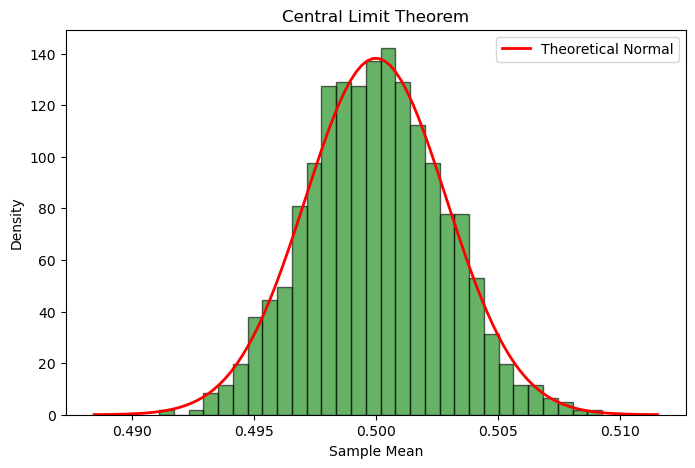

理论方差 = 0.00000833
实际样本方差 = 0.00000776


In [5]:
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(0)
n = 10000
m = 1000
# 1. 生成并计算样本均值
means = np.mean(np.random.rand(m, n), axis=1)

# 2. 绘制直方图并叠加理论曲线
plt.figure(figsize=(8,5))
count, bins, _ = plt.hist(means, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')

mu_theory = 0.5
sigma_theory = np.sqrt(1/12 / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', lw=2, label='Theoretical Normal')
plt.legend()
plt.title('Central Limit Theorem')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.show()

# 3. 计算均值的实际方差
actual_var = np.var(means, ddof=1)
print(f"理论方差 = {sigma_theory**2:.8f}")
print(f"实际样本方差 = {actual_var:.8f}")

4.1 理论计算题

In [8]:
from sympy import symbols, diff
w1, w2 = symbols('w1 w2')
x1_val, x2_val, y_val = 2, 1, 3
z = (w1*x1_val + w2*x2_val - y_val)**2

# 1. 计算偏导表达式
dz_dw1 = diff(z, w1)
dz_dw2 = diff(z, w2)
print("1. 偏导表达式:")
print(f"∂z/∂w1 = {dz_dw1}")
print(f"∂z/∂w2 = {dz_dw2}")

# 2. 代入具体数值计算梯度
w1_num, w2_num = 0.5, 1.0
grad_w1_val = dz_dw1.subs({w1: w1_num, w2: w2_num})
grad_w2_val = dz_dw2.subs({w1: w1_num, w2: w2_num})
print(f"\n2. 当 w1=0.5, w2=1 时:")
print(f"∂z/∂w1 = {grad_w1_val}")
print(f"∂z/∂w2 = {grad_w2_val}")

1. 偏导表达式:
∂z/∂w1 = 8*w1 + 4*w2 - 12
∂z/∂w2 = 4*w1 + 2*w2 - 6

2. 当 w1=0.5, w2=1 时:
∂z/∂w1 = -4.00000000000000
∂z/∂w2 = -2.00000000000000


4.2 编程题

In [10]:
import torch
x_val = 2.0
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 前向计算
a = x_val * w1
b = a + w2
L = b**2

print(f"前向结果: a={a.item():.2f}, b={b.item():.2f}, L={L.item():.2f}")

# 手动链式法则
b_val = b.item()
manual_grad_w1 = 2 * b_val * x_val
manual_grad_w2 = 2 * b_val
print(f"手动梯度: dL/dw1={manual_grad_w1:.2f}, dL/dw2={manual_grad_w2:.2f}")

# 自动微分
L.backward()
print(f"自动微分: dL/dw1={w1.grad.item():.2f}, dL/dw2={w2.grad.item():.2f}")

# 验证一致性
print("结果一致:", torch.allclose(w1.grad, torch.tensor(manual_grad_w1)) and 
                  torch.allclose(w2.grad, torch.tensor(manual_grad_w2)))

前向结果: a=3.00, b=3.50, L=12.25
手动梯度: dL/dw1=14.00, dL/dw2=7.00
自动微分: dL/dw1=14.00, dL/dw2=7.00
结果一致: True


5.1 理论计算题

In [11]:
n, i = symbols('n i', integer=True, positive=True)
x_i, y_i, w, b = symbols('x_i y_i w b')
# 均方误差损失函数 L = (1/n) * Σ(y_i - (w*x_i + b))^2
# 先对一个样本求导，再用求和表示
pred = w*x_i + b
error = y_i - pred
L_single = error**2   # 单个样本损失

dw = diff(L_single, w)
db = diff(L_single, b)

from sympy import Sum, Indexed
# 显式写出求和形式
L_total = (1/n) * Sum((y_i - (w*x_i + b))**2, (i, 1, n))
dw_total = diff(L_total, w)
db_total = diff(L_total, b)

print("单个样本的偏导:")
print(f"∂L/∂w = {dw}")
print(f"∂L/∂b = {db}")
print("\n总损失 L = (1/n) * Σ(y_i - (w*x_i + b))^2 的偏导:")
print(f"∂L/∂w = {dw_total}")
print(f"∂L/∂b = {db_total}")

单个样本的偏导:
∂L/∂w = -2*x_i*(-b - w*x_i + y_i)
∂L/∂b = 2*b + 2*w*x_i - 2*y_i

总损失 L = (1/n) * Σ(y_i - (w*x_i + b))^2 的偏导:
∂L/∂w = Sum(-2*x_i*(-b - w*x_i + y_i), (i, 1, n))/n
∂L/∂b = Sum(2*b + 2*w*x_i - 2*y_i, (i, 1, n))/n


5.2 编程题

Epoch 0, Loss: 1.7071
Epoch 10, Loss: 0.1562
Epoch 20, Loss: 0.1358
Epoch 30, Loss: 0.0000
Epoch 40, Loss: 0.0001
测试准确率: 0.9639


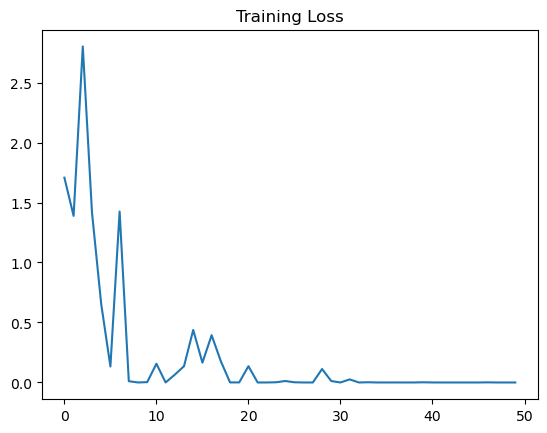

In [12]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target   # X: (1797, 64)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot 编码
def one_hot(labels, num_classes=10):
    return np.eye(num_classes)[labels]

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

# Softmax 和交叉熵
def softmax(logits):
    exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy(probs, labels):
    return -np.mean(np.sum(labels * np.log(probs + 1e-12), axis=1))

# 初始化参数
np.random.seed(0)
W = 0.01 * np.random.randn(64, 10)
b = np.zeros((1, 10))

# 训练
lr = 0.1
batch_size = 32
epochs = 50
losses = []
for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_shuf, y_shuf = X_train[idx], y_train_oh[idx]
    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuf[i:i+batch_size]
        y_batch = y_shuf[i:i+batch_size]
        logits = X_batch @ W + b
        probs = softmax(logits)
        loss = cross_entropy(probs, y_batch)
        # 梯度
        grad_logits = probs - y_batch
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.mean(grad_logits, axis=0, keepdims=True)
        W -= lr * grad_W
        b -= lr * grad_b
    losses.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# 测试准确率
logits_test = X_test @ W + b
y_pred = np.argmax(softmax(logits_test), axis=1)
acc = np.mean(y_pred == y_test)
print(f"测试准确率: {acc:.4f}")

plt.plot(losses)
plt.title('Training Loss')
plt.show()

6.1 理论计算题

In [15]:
from sympy import symbols, IndexedBase, sqrt, exp, Sum, Eq, diff, solve, log, pi

mu, sigma = symbols('mu sigma', positive=True)
xi = IndexedBase('x')
i, n = symbols('i n', integer=True, positive=True)

# 总似然函数（对数形式，保留 sigma）
logL = -n/2*log(2*pi) - n/2*log(sigma**2) - Sum((xi[i] - mu)**2, (i, 1, n))/(2*sigma**2)

# 对 mu 求导
eq_mu = Eq(diff(logL, mu), 0)
print("对 mu 求导：", eq_mu)
mu_hat = solve(eq_mu, mu)
print("mu 的 MLE 为：", mu_hat)   # 可能为 []，见下文说明

# 对 sigma^2 求偏导 —— 直接定义 sigma2 为符号
sigma2 = symbols('sigma2', positive=True)   # 方差作为一个独立符号
logL_s2 = -n/2*log(2*pi) - n/2*log(sigma2) - Sum((xi[i] - mu)**2, (i, 1, n))/(2*sigma2)
eq_s2 = Eq(diff(logL_s2, sigma2), 0)
sigma2_hat = solve(eq_s2, sigma2)
print("\n对 sigma^2 求导并令为0，解得 sigma^2 的 MLE 为：", sigma2_hat)

对 mu 求导： Eq(-Sum(2*mu - 2*x[i], (i, 1, n))/(2*sigma**2), 0)
mu 的 MLE 为： []

对 sigma^2 求导并令为0，解得 sigma^2 的 MLE 为： [Sum(mu**2 - 2*mu*x[i] + x[i]**2, (i, 1, n))/n]


6.2 编程题

Iter 0, Loss=0.6824
Iter 200, Loss=0.2049
Iter 400, Loss=0.2000
Iter 600, Loss=0.1993
Iter 800, Loss=0.1991


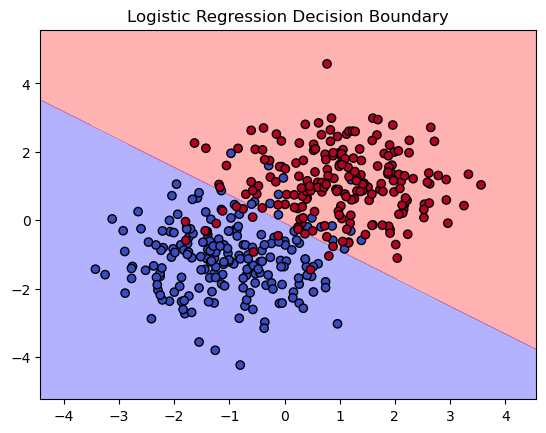

测试准确率: 0.8900


In [16]:
# 1. 生成数据
np.random.seed(123)
mean0, mean1 = [-1, -1], [1, 1]
cov = [[1,0],[0,1]]
X0 = np.random.multivariate_normal(mean0, cov, 200)
X1 = np.random.multivariate_normal(mean1, cov, 200)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(200), np.ones(200)]).reshape(-1,1)

X_test0 = np.random.multivariate_normal(mean0, cov, 50)
X_test1 = np.random.multivariate_normal(mean1, cov, 50)
X_test = np.vstack([X_test0, X_test1])
y_test = np.hstack([np.zeros(50), np.ones(50)]).reshape(-1,1)

# sigmoid 和损失
def sigmoid(z):
    return 1/(1+np.exp(-z))
def bce(y_true, y_pred):
    return -np.mean(y_true*np.log(y_pred+1e-12) + (1-y_true)*np.log(1-y_pred+1e-12))

# 梯度下降
np.random.seed(0)
w = 0.01 * np.random.randn(2,1)
b = 0.0
lr = 0.1
for i in range(1000):
    z = X @ w + b
    yp = sigmoid(z)
    loss = bce(y, yp)
    dz = yp - y
    dw = X.T @ dz / len(X)
    db = np.mean(dz)
    w -= lr * dw
    b -= lr * db
    if i % 200 == 0:
        print(f"Iter {i}, Loss={loss:.4f}")

# 决策边界可视化
x1_range = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_range = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]
probs = sigmoid(grid @ w + b).reshape(xx1.shape)

plt.contourf(xx1, xx2, probs, levels=[0,0.5,1], alpha=0.3, colors=['blue','red'])
plt.scatter(X[:,0], X[:,1], c=y.ravel(), edgecolors='k', cmap=plt.cm.coolwarm)
plt.title('Logistic Regression Decision Boundary')
plt.show()

# 测试准确率
z_test = X_test @ w + b
y_pred_test = (sigmoid(z_test) >= 0.5).astype(int)
acc = np.mean(y_pred_test == y_test)
print(f"测试准确率: {acc:.4f}")